# **FAST SHAPELETS RESULTS**

#### **Preliminary steps**

In [1]:
### PACKAGES

import numpy as np
import matplotlib.pyplot as plt

In [2]:
### FUNCTIONS

from src.preprocessing import load_data, z_normalize_2d, add_noise

from src.fast_shapelets import compute_fast_shapelets_parallelized

from src.evaluation import (
    find_classification_criterion,
    predict,
    compute_accuracy,
    run_experiments,
    compute_randomness,
    compute_noise_accuracy,
)

from src.visualization import (
    plot_shapelet,
    plot_series_with_shapelet,
    plot_confusion_matrix,
    plot_results_experiments,
    plot_results_noise,
    plot_results_randomness,
)

In [3]:
### CONSTANTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}

## **LOAD DATA**

In [4]:
### DATA

X_train, y_train = load_data("TRAIN")
X_test, y_test = load_data("TEST")

X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


In [5]:
### Z-NORMALIZE

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

## **FIND SHAPELET**

In [59]:
shapelet_params = compute_fast_shapelets_parallelized(
    X_train=X_train, y_train=y_train, params=PARAMS
)
find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=shapelet_params
)

In [60]:
shapelet_params["shapelet"].shape

(54,)

## **EVALUATION**

### **Metrics**

In [61]:
### PREDICTIONS

y_pred_train = predict(X_test=X_train, shapelet_params=shapelet_params)
y_pred_test = predict(X_test=X_test, shapelet_params=shapelet_params)

In [62]:
### ACCURACY

accuracy_train = compute_accuracy(y_true=y_train, y_pred=y_pred_train)
accuracy_test = compute_accuracy(y_true=y_test, y_pred=y_pred_test)

print(f"Accuracy on train set: {100*accuracy_train:.2f} %")
print(f"Accuracy on test set: {100*accuracy_test:.2f} %")

Accuracy on train set: 100.00 %
Accuracy on test set: 97.44 %


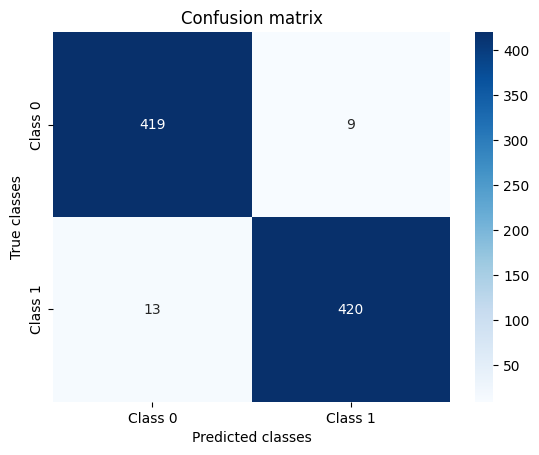

In [63]:
### CONFUSION MATRIX

plot_confusion_matrix(y_true=y_test, y_pred=y_pred_test)

### **Plots**

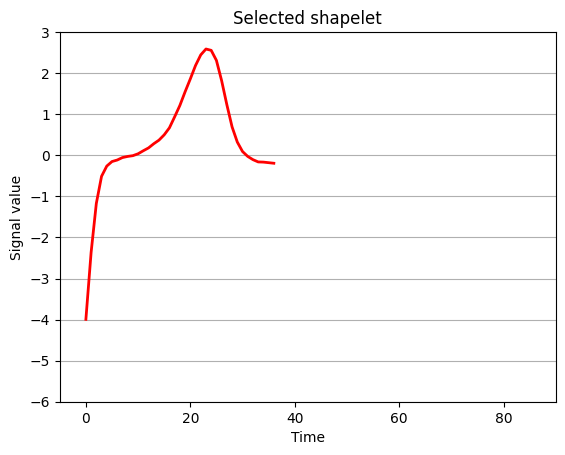

In [17]:
### SELECTED SHAPELET

plot_shapelet(shapelet_params=shapelet_params)

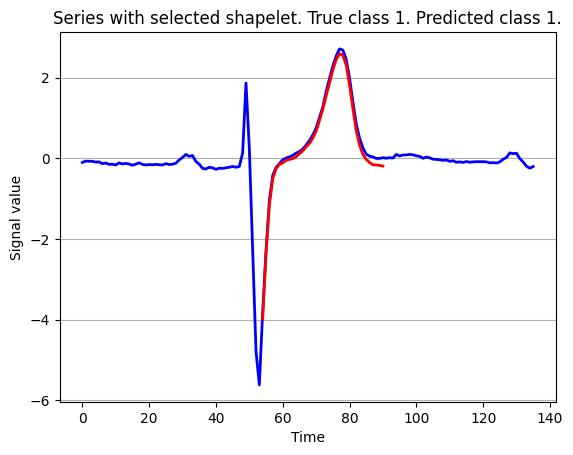

In [30]:
### PLOT SHAPELET ON A SERIES

SERIES_IDX = 111

plot_series_with_shapelet(
    X=X_test, y=y_test, shapelet_params=shapelet_params, index=SERIES_IDX
)

## **RANDOMNESS**

In [21]:
### DATA

X_train, y_train = load_data("TRAIN")
X_test, y_test = load_data("TEST")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


In [22]:
### COMPUTE RANDOMNESS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
iterations, train_accuracies, test_accuracies = compute_randomness(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    nb_times=20,
)

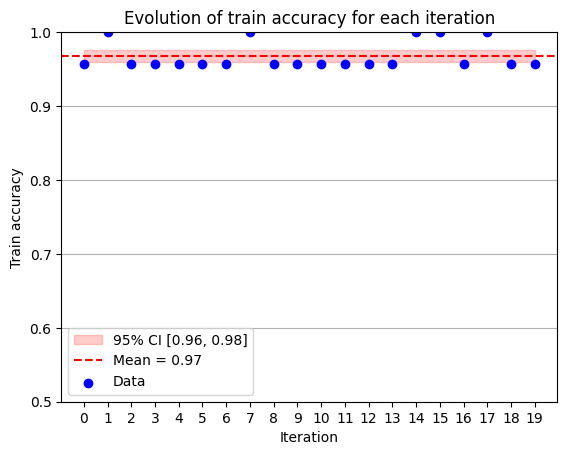

In [23]:
### PLOT : TRAIN ACCURACY

plot_results_randomness(
    iterations=iterations,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="train",
)

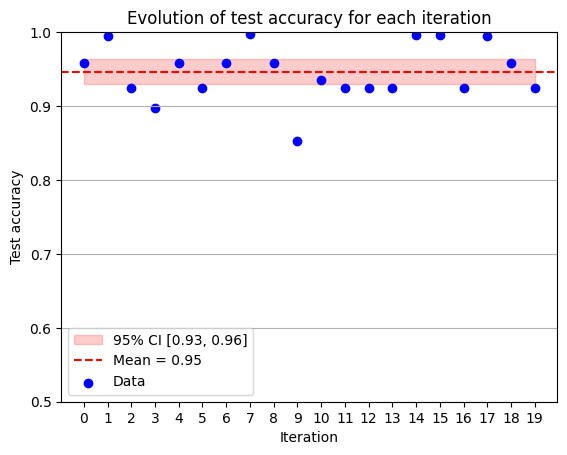

In [24]:
### PLOT : TEST ACCURACY

plot_results_randomness(
    iterations=iterations,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="test",
)

## **EXPERIMENTS**

### **Dimensionality**

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "dimensionality"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [38:23<00:00, 115.20s/it]


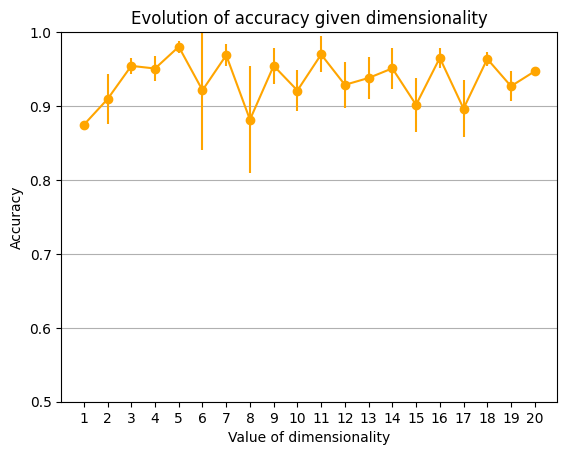

In [8]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

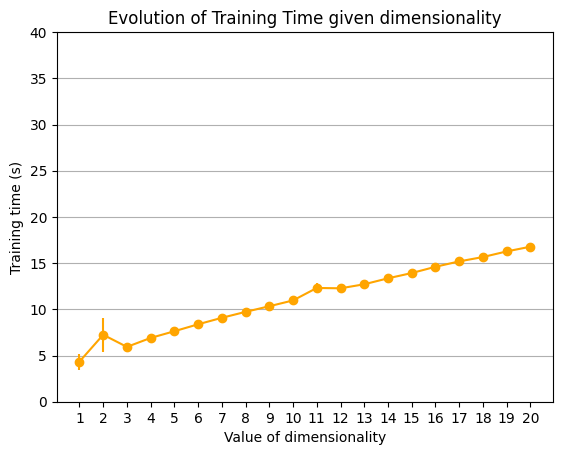

In [9]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="Training Time",
)

### **Cardinality**

In [10]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "cardinality"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [49:46<00:00, 149.33s/it]


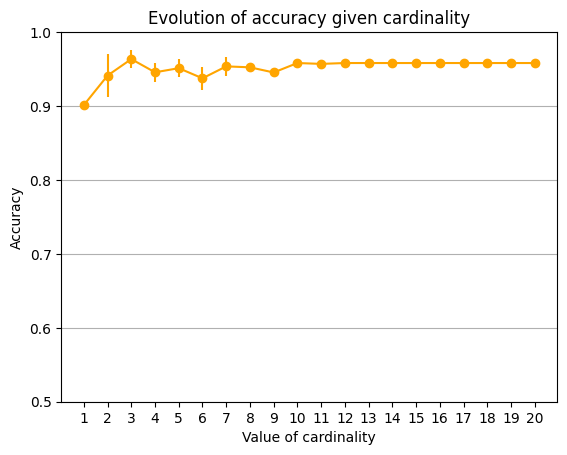

In [12]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

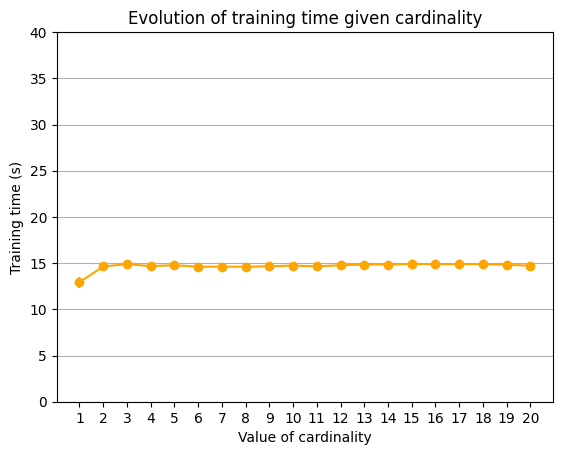

In [13]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

### **R**

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "r"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [49:56<00:00, 149.84s/it] 


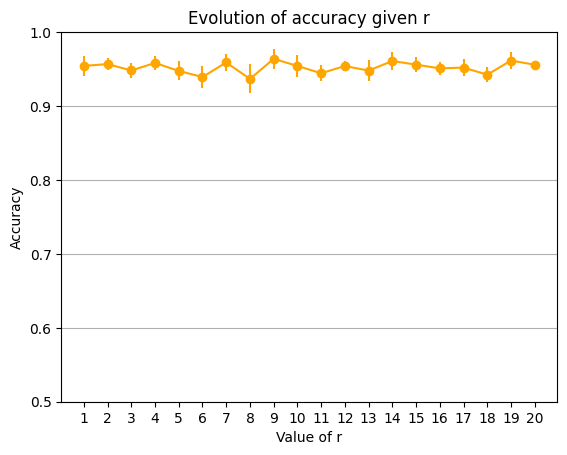

In [7]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

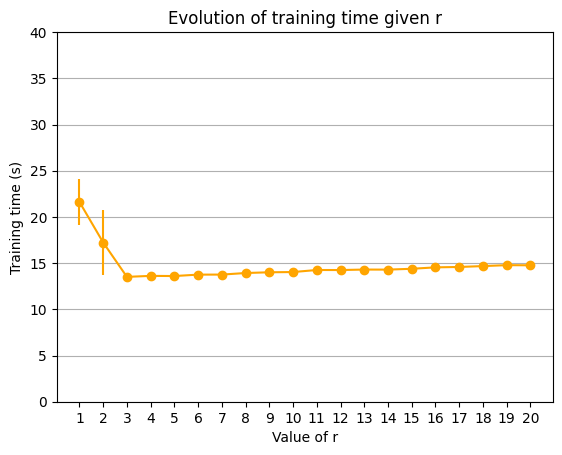

In [8]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

### **K**

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "k"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [49:48<00:00, 149.45s/it]


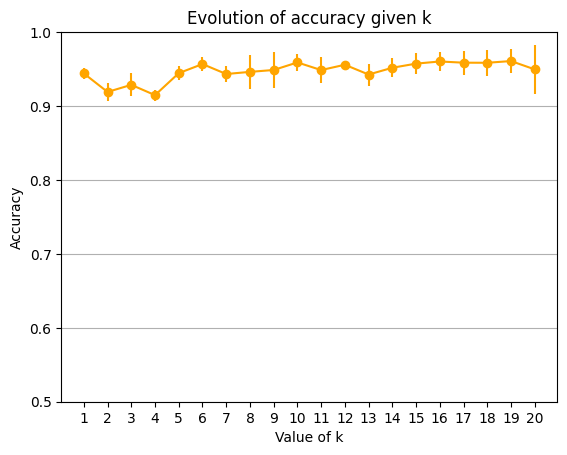

In [7]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

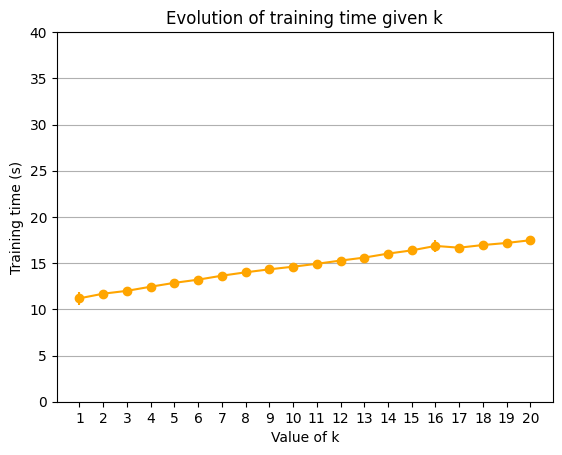

In [8]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

### **Proba**

In [9]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "proba"
VALUES = np.linspace(start=0.1, stop=1, num=10)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 10/10 [24:32<00:00, 147.26s/it]


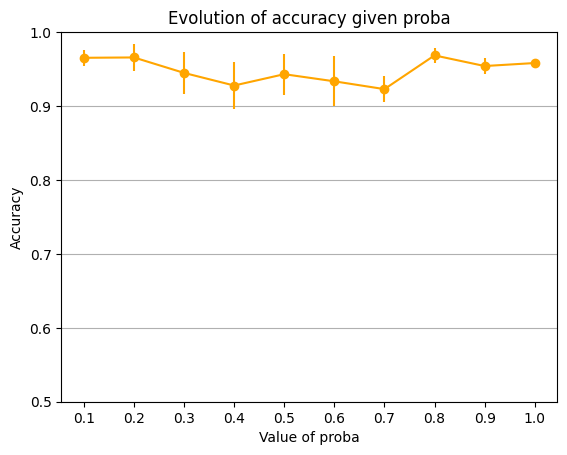

In [10]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

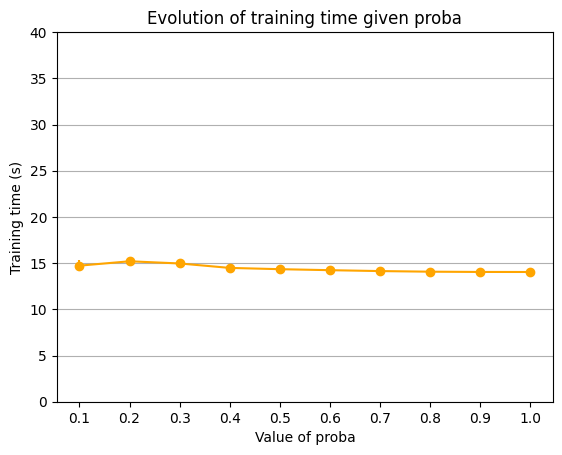

In [11]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)

## **NOISE IN DATA**

In [3]:
SIGMAS = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
X_train, y_train = load_data("TRAIN")
X_test, y_test = load_data("TEST")

X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


### **Noise in test data**

In [4]:
### COMPUTE ACCURACIES

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
sigmas, knn_accuracies, shapelet_accuracies = compute_noise_accuracy(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    sigmas=SIGMAS,
    noise="test",
    nb_times=10,
)

100%|██████████| 9/9 [22:48<00:00, 152.02s/it]


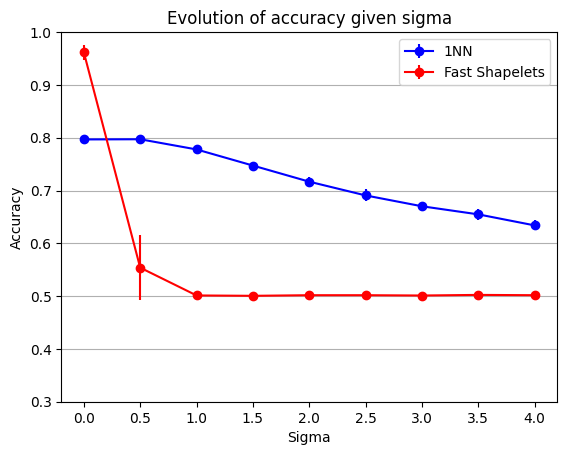

In [5]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    knn_accuracies=knn_accuracies,
    shapelet_accuracies=shapelet_accuracies,
)

### **Noise in both train and test data**

In [6]:
### COMPUTE ACCURACIES

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
sigmas, knn_accuracies, shapelet_accuracies = compute_noise_accuracy(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    sigmas=SIGMAS,
    noise="both",
    nb_times=10,
)

100%|██████████| 9/9 [22:15<00:00, 148.41s/it]


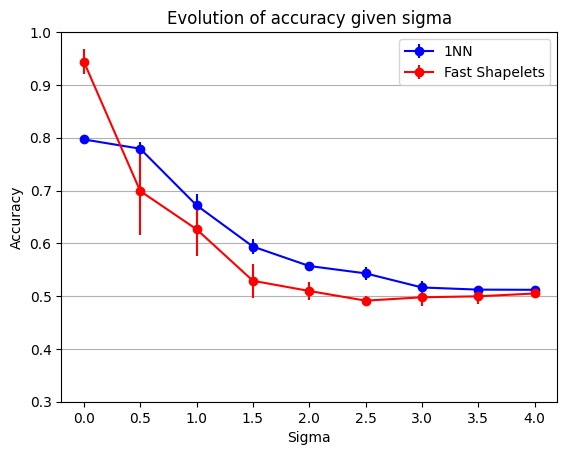

In [7]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    knn_accuracies=knn_accuracies,
    shapelet_accuracies=shapelet_accuracies,
)